# Data Science Camp 2026  
## Task 2

## Task Description

Consider a matrix of size 26 × 26 filled randomly with binary values:
- 0 means the cell is dead,
- 1 means the cell is alive.

The following image represents a sample where green cells are equal to 1
and grey cells are equal to 0.

### Objectives:
1. Develop an algorithm that accepts the specified binary array of size
   26 × 26 and iterates the steps where each step executes the following rules:
   - If a living cell has two or three living neighbors, it remains alive;
   - If a living cell has one or no living neighbors, it dies of loneliness;
   - If a living cell has four or more living neighbors, it dies from overpopulation;
   - If a dead cell has exactly three living neighbors, it comes to life.
2. (Optional) Visualize the process of execution steps.

The solution must be implemented using programming code in a Jupyter Notebook,
Google Colab, or a similar environment, and must include:
1. Generating the matrix of size 26 × 26 with binary random values,
2. An algorithm that executes iterations over the given rules,
3. The matrix of values after 20 executed steps.


## Libraries Used

numpy — work with matrices and numerical operations  
matplotlib.pyplot — visualization


In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Matrix initialization

A binary matrix of size 26 × 26 is generated randomly.
Each cell contains either 0 (dead) or 1 (alive).


In [2]:
# generate random 26x26 binary matrix
grid = np.random.randint(0, 2, size=(26, 26))

## Algorithm rules

At each iteration step, the state of every cell is updated according to
the following rules:

- If a living cell has two or three living neighbors, it remains alive.
- If a living cell has one or no living neighbors, it dies of loneliness.
- If a living cell has four or more living neighbors, it dies from overpopulation.
- If a dead cell has exactly three living neighbors, it becomes alive.


In [3]:
def count_neighbors(grid: np.ndarray) -> np.ndarray:
    # count how many living neighbors each cell has
    g = np.pad(grid, 1, mode="constant", constant_values=0)
    return (
        g[:-2, :-2] + g[:-2, 1:-1] + g[:-2, 2:] +
        g[1:-1, :-2]              + g[1:-1, 2:] +
        g[2:, :-2] + g[2:, 1:-1] + g[2:, 2:]
    )


def step_game_of_life(grid: np.ndarray) -> np.ndarray:
    # apply one iteration of the rules
    neighbors = count_neighbors(grid)

    alive = grid == 1
    dead = ~alive

    new_grid = grid.copy()

    # living cell rules
    new_grid[alive & ((neighbors <= 1) | (neighbors >= 4))] = 0
    new_grid[alive & ((neighbors == 2) | (neighbors == 3))] = 1

    # dead cell rule
    new_grid[dead & (neighbors == 3)] = 1

    return new_grid

## Iteration process

The algorithm is executed for 20 steps, where the rules are applied
to the entire matrix at each step.


In [4]:
steps = 20
current = grid.copy()

# apply the rules step by step
for _ in range(steps):
    current = step_game_of_life(current)

final_grid = current
final_grid

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0],
       [0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
        1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
        0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

## Saving results

After completing the iterations, the following results are saved:
- the initial matrix visualization,
- the final matrix visualization after 20 steps,
- the final matrix values in text format.


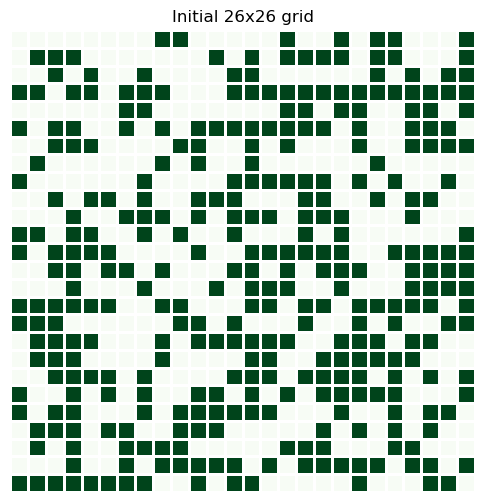

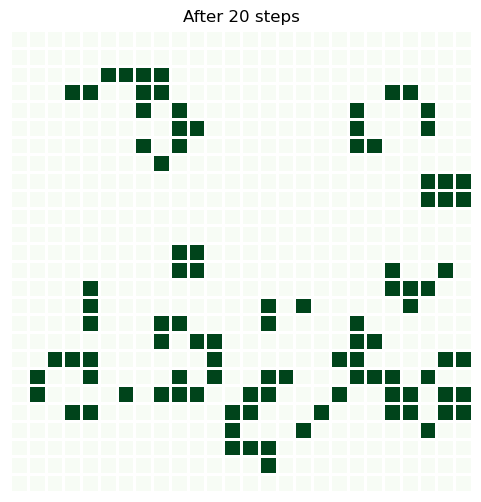

In [5]:
# save results
np.savetxt("task2_final_matrix.txt", final_grid, fmt="%d")

# initial grid
plt.figure(figsize=(6, 6))
plt.pcolormesh(grid, cmap="Greens", edgecolors="white", linewidth=1)
plt.title("Initial 26x26 grid")
plt.axis("off")
plt.savefig("task2_initial.png", dpi=200, bbox_inches="tight")
plt.show()

# final grid
plt.figure(figsize=(6, 6))
plt.pcolormesh(final_grid[::-1], cmap="Greens", edgecolors="white", linewidth=1)
plt.title("After 20 steps")
plt.gca().set_aspect("equal")
plt.axis("off")
plt.savefig("task2_after_20.png", dpi=200, bbox_inches="tight")
plt.show()

## Final matrix output

The final matrix obtained after **20 iterations** is printed below.


In [6]:
for row in final_grid:
    print(" ".join(map(str, row)))

0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 1 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0
0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0
0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0
0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0
0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0
0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0
0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0
0 0 0 0 1 0 0 0 1 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0
0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0
0 0 1 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 1 1
0 1 0 0 1 0 

## Conclusion

A 26 × 26 binary matrix was generated and processed using the given rules.
After 20 steps, the final matrix was obtained and visualized.
